# Train SBI baseline (Self-Blended Images) — Shiohara & Yamasaki, CVPR 2022

Bám sát `Detecting Deepfakes with Self-Blended Images` (Section 3, Algorithm 1, Section 4.1).
**Điểm khác biệt cốt lõi so với UCF/Xception:** SBI **KHÔNG cần video fake nào để train** —
toàn bộ fake sample được sinh **on-the-fly** bằng cách tự-blend (self-blend) 1 ảnh real với
chính nó (đã biến đổi màu/tần số + resize/translate), dùng landmark khuôn mặt để tạo mask blend.

## 📋 Kaggle Input cần add
| # | Dataset | Ghi chú |
|---|---|---|
| 1 | `thinhphan272/ffpp-c23-face-cache` | Cache khuôn mặt đã crop (dùng chung với UCF/Xception) — SBI chỉ dùng phần **real** để train/val, dùng **cả real+fake** để đánh giá test cuối theo đúng protocol thống nhất của dự án |

Bật **Internet ON** (cần tải `dlib` + file shape predictor 81 điểm mốc).

## ⚠️ CÁC THAM SỐ XẤP XỈ (không có trong phần chính bài báo, chỉ có công thức ký hiệu ở
Algorithm 1 / Section 3.1, số liệu cụ thể nằm ở phụ lục — supplementary material — không có
trong file PDF được cung cấp). Notebook này dùng giá trị hợp lý, có ghi chú rõ tại từng chỗ:
- Khoảng resize/translate của STG: `u∈[0.7,1.3]`, `v∈[-0.25,0.25]` (paper chỉ cho công thức
  `Hr=u_h·H`, không cho số `u_min,u_max` cụ thể trong phần text được trích).
- Kernel 2 phép Gaussian blur của Mask Generator: chọn ngẫu nhiên trong `{5,7,9,11}` (paper mô
  tả đúng cơ chế "2 Gaussian filter khác kernel → ăn mòn/giãn nở mask" nhưng không cho số kernel
  cụ thể).
- Nhiễu loạn landmark trước khi tính Convex Hull ("landmark transformation as used in BI"): xấp
  xỉ bằng nhiễu Gauss nhỏ theo kích thước khuôn mặt (paper chỉ dẫn chiếu sang code Face X-ray,
  không mô tả công thức trong bài).
- Optimizer SAM: paper chỉ ghi "trained with the SAM optimizer", không nêu rõ base optimizer
  trong phần text được trích — dùng `SGD(momentum=0.9)` làm base optimizer (lựa chọn phổ biến
  nhất khi dùng SAM, theo cài đặt tham khảo công khai của SAM).
- Xác suất áp dụng từng augmentation màu/tần số/nén: paper chỉ liệt kê TÊN augmentation dùng
  (RGBShift, HueSaturationValue, RandomBrightnessContrast, Downscale, Sharpen, ImageCompression
  — đúng từ thư viện Albumentations mà paper trích dẫn [12]), không nêu xác suất `p` cụ thể.

**Không xấp xỉ (lấy đúng số trong bài):** backbone EfficientNet-b4 pretrained ImageNet, batch
size=32, lr=0.001, 100 epoch, 8 khung hình/video để train, blending ratio `r` lấy từ
`{0.25,0.5,0.75,1,1,1}`, loss BCE (Eq. 2, gán nhãn ảnh target = "Real"), TTA/breakdown/CSV output
theo đúng quy ước thống nhất của dự án (giống UCF/Xception) để so sánh được giữa 5 model.


## 1. Cấu hình

In [1]:
import os, glob, time, random, json, math, bz2, urllib.request
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR    = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"  # SỬA nếu khác — dùng chung cache với UCF/Xception
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX   = "/kaggle/working/ffpp_c23_cache"
assert os.path.isdir(CACHE_DIR), f"Not found: {CACHE_DIR}"
assert os.path.exists(MANIFEST_CSV), f"Not found: {MANIFEST_CSV}"

# ==================== HYPERPARAMETERS (đúng paper Section 4.1) ====================
IMG_SIZE      = 380          # EfficientNet-b4 resolution gốc
BATCH_SIZE    = 32           # paper: batch_size=32
LR            = 0.001        # paper: lr=0.001
SAM_RHO       = 0.05         # paper không nêu rho cụ thể -- 0.05 là giá trị mặc định phổ biến của SAM
N_EPOCHS      = 100          # paper: "trained for 100 epochs"
PATIENCE      = 10           # đồng bộ quy ước patience=10 của dự án (paper không early-stop)
FRAMES_PER_VIDEO_TRAIN = 8   # paper: "we sample only eight frames per video for training"
SEED          = 42
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP       = True         # SỬA: bật lại AMP -- fp32 @ IMG_SIZE=380, batch=32, EfficientNet-B4
                              # là nguyên nhân gây CUDA OOM (GPU dùng hết 14.53/14.56 GiB ngay
                              # batch đầu tiên). Dùng autocast(fp16) KHÔNG kèm GradScaler (SAM có
                              # logic 2-bước tùy biến không tương thích trực tiếp với
                              # scaler.step()) -- autocast đơn thuần vẫn đủ ổn định cho BCE loss.
GRAD_CHECKPOINTING = True    # SỬA: bật gradient checkpointing cho backbone để giảm thêm bộ nhớ
                              # activation (đánh đổi ít thời gian tính lại forward), an toàn hơn
                              # cho GPU 14.6GB ở độ phân giải 380x380.

# ---- Quy ước thống nhất cho CSV kết quả cuối (đồng bộ với UCF/Xception) ----
# Paper tự chọn checkpoint theo quy tắc RIÊNG (Section 4.1 "Model Validation"): giữ 5 checkpoint
# có val_auc cao nhất, rồi chọn trong 5 cái đó checkpoint có epoch LỚN NHẤT (mới nhất). Đây là
# quy tắc đặc thù của bài báo SBI (khác UCF/Xception dùng thẳng val_auc cao nhất) -- giữ nguyên
# đúng paper vì đây là baseline cần bám sát, không đơn giản hoá.
CHECKPOINT_CRITERION = "val_auc"    # đồng bộ master prompt Phần 1 mục 1 (chọn checkpoint có val_auc CAO NHẤT trên val real+fake thật)
TTA_USED = "hflip"          # quy ước TTA thống nhất của dự án cho bước test cuối (paper không dùng TTA)
EPOCH_TIMES = []            # tích lũy thời gian (giây)/epoch để tính gpu_hours lúc test

OUT_DIR = "/kaggle/working/sbi_v1"
os.makedirs(OUT_DIR, exist_ok=True)
CKPT_DIR = os.path.join(OUT_DIR, "top5_ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Device:", DEVICE, "| IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE)


Device: cuda | IMG_SIZE: 380 | BATCH_SIZE: 32


## 2. Đọc manifest — SBI chỉ cần video REAL để train/val

Khác UCF/Xception: `train_df`/`val_df` ở đây **chỉ giữ video real** (label=0) vì SBI tự sinh
fake sample từ chính ảnh real. `test_df` vẫn giữ đủ real+fake để đánh giá cuối theo đúng
protocol thống nhất của dự án (so sánh ngang hàng với 4 model kia).

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)

if "method" not in manifest.columns:
    def infer_method(row):
        if row["label"] == 0: return "original"
        for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
            if m.lower() in row["out_dir"].lower() or m in row["out_dir"]:
                return m
        return "unknown"
    manifest["method"] = manifest.apply(infer_method, axis=1)

train_real_df = manifest[(manifest.split == "train") & (manifest.label == 0)].reset_index(drop=True)
val_real_df   = manifest[(manifest.split == "val")   & (manifest.label == 0)].reset_index(drop=True)

# THÊM: val_df gồm CẢ real + fake thật — dùng cho checkpoint selection + early stopping
# (đồng bộ master prompt Phần 4: "hãy dùng val_df gốc thay vì val riêng theo paper")
val_df = manifest[manifest.split == "val"].reset_index(drop=True)
test_df       = manifest[manifest.split == "test"].reset_index(drop=True)   # real+fake, dùng cho đánh giá cuối

print(f"Train video REAL: {len(train_real_df)} | Val video REAL (SBI): {len(val_real_df)} "
      f"| Val video (real+fake): {len(val_df)} | Test video (real+fake): {len(test_df)}")
print("Methods trong test:", test_df["method"].value_counts().to_dict())


Train video REAL: 720 | Val video REAL (SBI): 140 | Val video (real+fake): 700 | Test video (real+fake): 700
Methods trong test: {'original': 140, 'Deepfakes': 140, 'Face2Face': 140, 'FaceSwap': 140, 'NeuralTextures': 140}


## 3. Cài `dlib` + tải shape predictor 81 điểm mốc

Paper dùng đúng bộ 81-facial-landmarks shape predictor của Dlib (paper ref [1],
`codeniko/shape_predictor_81_face_landmarks`). Chỉ cần dlib để lấy landmark phục vụ Mask
Generator — không cần RetinaFace vì ảnh vào đã là khuôn mặt crop sẵn từ cache chung của dự án.

In [3]:
!pip install -q dlib

import dlib

SHAPE_PREDICTOR_PATH = "/kaggle/working/shape_predictor_81_face_landmarks.dat"
if not os.path.exists(SHAPE_PREDICTOR_PATH):
    url = ("https://github.com/codeniko/shape_predictor_81_face_landmarks/"
           "raw/master/shape_predictor_81_face_landmarks.dat")
    print("Đang tải shape predictor 81 điểm mốc...")
    urllib.request.urlretrieve(url, SHAPE_PREDICTOR_PATH)
print("File size:", os.path.getsize(SHAPE_PREDICTOR_PATH) / 1e6, "MB")

dlib_detector = dlib.get_frontal_face_detector()
dlib_predictor = dlib.shape_predictor(SHAPE_PREDICTOR_PATH)
print("OK - dlib detector + 81-point predictor sẵn sàng.")


Đang tải shape predictor 81 điểm mốc...
File size: 19.74386 MB
OK - dlib detector + 81-point predictor sẵn sàng.


## 4. Trích landmark 81 điểm cho các khung hình train/val (tính 1 LẦN, dùng lại mỗi epoch)

Paper: *"the procedure is slightly different from Fig. 3 for training efficiency (e.g., facial
landmarks are extracted in preprocess but not in training)"*. Vì vậy ta cố định trước
`FRAMES_PER_VIDEO_TRAIN=8` khung hình/video real, trích landmark 1 lần, cache lại — không dò
landmark lại ở mỗi epoch.

Vì ảnh đầu vào đã là khuôn mặt crop sẵn (không phải khung hình gốc), nếu `dlib_detector` không
tìm thấy mặt (khả năng thấp do ảnh đã được crop khá sát), dùng cả khung ảnh làm vùng mặt fallback
cho `shape_predictor`.

In [4]:
def sample_frame_paths(out_dir, k=FRAMES_PER_VIDEO_TRAIN, seed_offset=0):
    files = sorted(glob.glob(os.path.join(out_dir, "*.jpg")))
    if len(files) == 0: return []
    if len(files) <= k: return files
    idxs = np.linspace(0, len(files) - 1, k).astype(int)
    return [files[i] for i in idxs]


def detect_landmarks_81(img_bgr, detector, predictor):
    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = detector(gray, 1)
    if len(faces) > 0:
        rect = max(faces, key=lambda r: r.width() * r.height())
    else:
        rect = dlib.rectangle(0, 0, w - 1, h - 1)   # fallback: ảnh đã là mặt crop sẵn
    shape = predictor(gray, rect)
    pts = np.array([[p.x, p.y] for p in shape.parts()], dtype=np.float32)   # (81, 2)
    return pts


def build_landmark_cache(df, k, tag):
    items = []
    n_fail = 0
    for row in tqdm(df.itertuples(), total=len(df), desc=f"Landmarks ({tag})"):
        paths = sample_frame_paths(row.out_dir, k)
        for p in paths:
            img = cv2.imread(p)
            if img is None:
                n_fail += 1; continue
            try:
                lm = detect_landmarks_81(img, dlib_detector, dlib_predictor)
                items.append((p, lm))
            except Exception:
                n_fail += 1
    print(f"  → {len(items)} ảnh có landmark, {n_fail} ảnh lỗi/bỏ qua")
    return items

train_items = build_landmark_cache(train_real_df, FRAMES_PER_VIDEO_TRAIN, "train")
val_items   = build_landmark_cache(val_real_df,   2, "val")   # ít khung hình hơn cho val để nhanh
print(f"Tổng ảnh train: {len(train_items)} | val: {len(val_items)}")


Landmarks (train): 100%|██████████| 720/720 [03:32<00:00,  3.40it/s]


  → 5760 ảnh có landmark, 0 ảnh lỗi/bỏ qua


Landmarks (val): 100%|██████████| 140/140 [00:11<00:00, 12.23it/s]

  → 280 ảnh có landmark, 0 ảnh lỗi/bỏ qua
Tổng ảnh train: 5760 | val: 280


## 5. Source-Target Generator (STG) + Mask Generator (MG) — Algorithm 1

Cài đặt đúng 16 dòng pseudocode của Algorithm 1 trong paper:
1. `T(I)`: color transform + frequency transform, áp dụng cho MỘT trong hai ảnh source/target
   (tung đồng xu 50/50 — dòng 5-8).
2. Resize & Translate ảnh source theo `u_h,u_w ~ U[u_min,u_max]`, `v_h,v_w ~ U[v_min,v_max]`
   (dòng 9, công thức Section 3.1).
3. Nhiễu loạn landmark (dòng 10, "landmark transformation as used in BI") → Convex Hull (dòng 11)
   → áp CÙNG tham số resize/translate của source vào mask để căn đúng vị trí (dòng 12) →
   `MaskDeform` = elastic deform + 2 Gaussian blur khác kernel (dòng 13, Section 3.2).
4. Nhân mask với tỉ lệ blend `r ~ Uniform({0.25,0.5,0.75,1,1,1})` (dòng 14-15).
5. Blend: `I_SB = I_s⊙M + I_t⊙(1-M)` (dòng 16, Eq. 1).

In [5]:
import albumentations as alb

# ---- STG: color + frequency transform (đúng tên augmentation nêu trong paper Section 4.1,
# xác suất p cụ thể không có trong bài -- chọn giá trị hợp lý) ----
def get_source_transforms():
    return alb.Compose([
        alb.RGBShift((-20, 20), (-20, 20), (-20, 20), p=0.3),
        alb.HueSaturationValue(hue_shift_limit=0.3 * 255, sat_shift_limit=0.3 * 255,
                               val_shift_limit=0.3 * 255, p=0.3),
        alb.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.3),
        alb.OneOf([
            alb.Downscale(scale_min=0.625, scale_max=0.99, p=1.0),
            alb.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
        ], p=0.5),
    ], p=1.0)

SOURCE_TRANSFORM = get_source_transforms()
_ELASTIC = alb.ElasticTransform(alpha=50, sigma=7, p=1.0)


def color_freq_transform(img_rgb_uint8):
    return SOURCE_TRANSFORM(image=img_rgb_uint8)["image"]


def center_fit(img, H, W):
    """Zero-pad hoặc center-crop `img` về đúng kích thước (H, W) — dùng cho bước Resize (Section 3.1)."""
    h, w = img.shape[:2]
    if img.ndim == 3:
        canvas = np.zeros((H, W, img.shape[2]), dtype=img.dtype)
    else:
        canvas = np.zeros((H, W), dtype=img.dtype)
    y_off, x_off = (H - h) // 2, (W - w) // 2
    src_y0, src_y1 = max(0, -y_off), min(h, H - y_off)
    src_x0, src_x1 = max(0, -x_off), min(w, W - x_off)
    dst_y0 = max(0, y_off); dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x0 = max(0, x_off); dst_x1 = dst_x0 + (src_x1 - src_x0)
    canvas[dst_y0:dst_y1, dst_x0:dst_x1] = img[src_y0:src_y1, src_x0:src_x1]
    return canvas


def resize_translate(img, H, W, uh, uw, th, tw):
    """Đúng công thức Section 3.1: resize theo (uh,uw) rồi zero-pad/center-crop về (H,W),
    rồi translate theo vector (th,tw)."""
    hr, wr = max(int(round(H * uh)), 1), max(int(round(W * uw)), 1)
    interp = cv2.INTER_LINEAR if img.ndim == 3 else cv2.INTER_NEAREST
    resized = cv2.resize(img, (wr, hr), interpolation=interp)
    fitted = center_fit(resized, H, W)
    Mt = np.float32([[1, 0, tw], [0, 1, th]])
    out = cv2.warpAffine(fitted, Mt, (W, H), borderValue=0)
    return out


def perturb_landmarks(landmarks, W, H, jitter_ratio=0.01):
    """Xấp xỉ 'landmark transformation as used in BI [40]': nhiễu Gauss nhỏ theo kích thước mặt
    để convex hull không trùng khít viền mặt thật (paper không cho công thức cụ thể trong bài)."""
    face_size = max(landmarks[:, 0].max() - landmarks[:, 0].min(),
                    landmarks[:, 1].max() - landmarks[:, 1].min(), 1.0)
    noise = np.random.normal(0, jitter_ratio * face_size, landmarks.shape)
    out = landmarks + noise
    out[:, 0] = np.clip(out[:, 0], 0, W - 1)
    out[:, 1] = np.clip(out[:, 1], 0, H - 1)
    return out


def convex_hull_mask(landmarks, H, W):
    mask = np.zeros((H, W), dtype=np.uint8)
    hull = cv2.convexHull(landmarks.astype(np.int32))
    cv2.fillConvexPoly(mask, hull, 1)
    return mask.astype(np.float32)


def dual_gaussian_threshold(mask, k1, k2):
    """Đúng cơ chế Section 3.2: 2 Gaussian blur khác kernel -> ăn mòn nếu k1>k2, giãn nở nếu
    k1<k2 (kernel cụ thể không có trong bài -- chọn ngẫu nhiên trong {5,7,9,11})."""
    m1 = cv2.GaussianBlur(mask, (k1, k1), 0)
    m1[m1 < 1.0] = 0.0
    m2 = cv2.GaussianBlur(m1, (k2, k2), 0)
    return m2


def generate_sbi(img_bgr, landmarks, u_range=(0.9, 1.1), v_range=(-0.06, 0.06)):
    # SỬA: u_range/v_range cũ (0.7-1.3, ±25%) tạo méo/dịch quá mạnh -> artifact "bóng ma" lộ
    # liễu, dễ đoán bất thường (SBI-val AUC ~0.99 ngay epoch 1) nhưng KHÔNG giống artifact
    # deepfake thật -> model không tổng quát hoá (RF-val AUC chỉ ~0.7, phần lớn fake thật bị
    # đoán "Real"). Thu hẹp về ±10% resize, ±6% dịch chuyển -- gần với mismatch tinh vi mà
    # paper mô tả (landmark mismatch nhỏ, không phải nhân đôi khuôn mặt).
    """Toàn bộ Algorithm 1. Trả về (fake_rgb_uint8, real_rgb_uint8)."""
    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # dòng 5-8: T(I) áp dụng cho MỘT trong hai ảnh
    if random.random() < 0.5:
        Is, It = color_freq_transform(img_rgb.copy()), img_rgb.copy()
    else:
        Is, It = img_rgb.copy(), color_freq_transform(img_rgb.copy())

    # dòng 9: RandomResizeTranslate(Is) -> p=(uh,uw,th,tw)
    uh, uw = random.uniform(*u_range), random.uniform(*u_range)
    th = int(round(random.uniform(*v_range) * H))
    tw = int(round(random.uniform(*v_range) * W))
    Is_rt = resize_translate(Is, H, W, uh, uw, th, tw)

    # dòng 10-13: LandmarkTransform -> ConvexHull -> ParameterizedResizeTranslate -> MaskDeform
    L_pert = perturb_landmarks(landmarks, W, H)
    M0 = convex_hull_mask(L_pert, H, W)
    M1 = resize_translate(M0, H, W, uh, uw, th, tw)
    M2 = _ELASTIC(image=M1)["image"]
    k1, k2 = random.choice([5, 7, 9, 11]), random.choice([5, 7, 9, 11])
    M3 = dual_gaussian_threshold(M2, k1, k2)

    # dòng 14-15: blending ratio r
    r = random.choice([0.25, 0.5, 0.75, 1, 1, 1])
    M_final = np.clip(M3 * r, 0, 1)[..., None]

    # dòng 16: blend (Eq. 1)
    Isb = (Is_rt.astype(np.float32) * M_final + It.astype(np.float32) * (1 - M_final))
    Isb = np.clip(Isb, 0, 255).astype(np.uint8)
    return Isb, It   # Isb = fake (label=1), It = "target" luôn gán nhãn Real (Section 3.4)


## 5b. SỬA: Sanity-check trực quan SBI (kiểm tra artifact trước khi train)

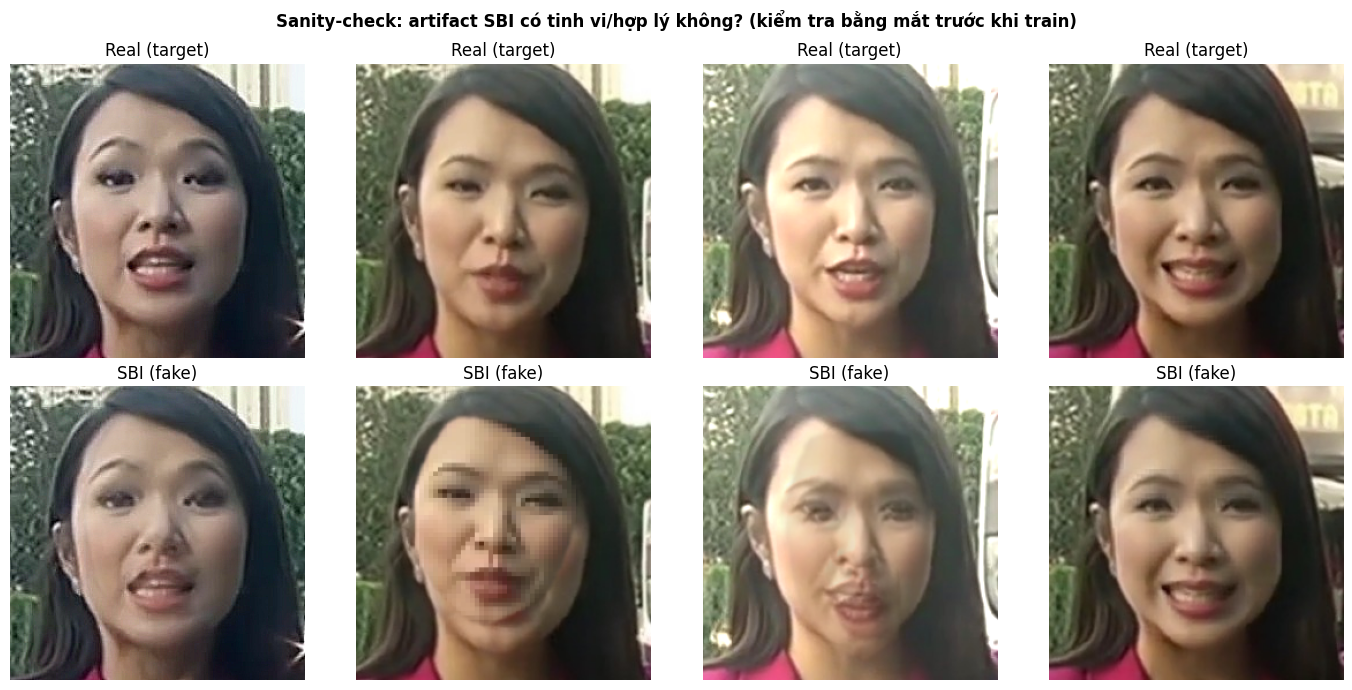

Nếu artifact quá lộ liễu (viền cứng, 'bóng ma' rõ rệt) -> giảm thêm u_range/v_range trong generate_sbi() rồi chạy lại cell này trước khi train toàn bộ.


In [6]:
# SỬA: thêm sanity-check trực quan (paper Fig.4 làm điều này, notebook gốc bỏ qua) --
# lưu vài cặp (real, SBI-fake) ra ảnh trước khi train để mắt thường kiểm tra artifact có
# tinh vi/hợp lý hay không, tránh lặp lại lỗi warp quá mạnh như trước.
import matplotlib.pyplot as plt

_sample_items = train_items[:4]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, (path, lm) in enumerate(_sample_items):
    img_bgr = cv2.imread(path)
    fake_rgb, real_rgb = generate_sbi(img_bgr, lm)
    axes[0, j].imshow(real_rgb); axes[0, j].set_title("Real (target)"); axes[0, j].axis("off")
    axes[1, j].imshow(fake_rgb); axes[1, j].set_title("SBI (fake)"); axes[1, j].axis("off")
plt.suptitle("Sanity-check: artifact SBI có tinh vi/hợp lý không? (kiểm tra bằng mắt trước khi train)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sbi_sample_check.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Nếu artifact quá lộ liễu (viền cứng, 'bóng ma' rõ rệt) -> giảm thêm u_range/v_range "
      "trong generate_sbi() rồi chạy lại cell này trước khi train toàn bộ.")


## 6. Dataset & DataLoader

Mỗi item = 1 cặp (ảnh real "target", ảnh SBI "fake") sinh từ CÙNG 1 ảnh gốc. Áp dụng CÙNG một
phép augmentation hậu-blend (`ImageCompression, RGBShift, HueSaturationValue,
RandomBrightnessContrast` — đúng danh sách nêu ở Section 4.1) cho cả 2 ảnh trong cặp, theo đúng
câu *"the same augmentation is applied to each real image and its SBI"*.

In [7]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

POST_AUG = alb.Compose([
    alb.ImageCompression(quality_lower=40, quality_upper=100, p=0.5),
    alb.RGBShift((-10, 10), (-10, 10), (-10, 10), p=0.3),
    alb.HueSaturationValue(hue_shift_limit=0.1 * 255, sat_shift_limit=0.1 * 255,
                           val_shift_limit=0.1 * 255, p=0.3),
    alb.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
], additional_targets={"image1": "image"})   # additional_targets -> cùng 1 random state cho 2 ảnh


def to_tensor_norm(img_rgb_uint8):
    img_f = img_rgb_uint8.astype(np.float32) / 255.0
    inp = (img_f - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(inp.transpose(2, 0, 1)).float()


class SBIDataset(Dataset):
    """items: list[(frame_path, landmarks_81x2)]. __getitem__ sinh SBI on-the-fly mỗi lần gọi
    (khác với UCF paired-dataset chỉ CHỌN sẵn ảnh có sẵn -- ở đây ảnh fake được TẠO MỚI mỗi lần)."""
    def __init__(self, items):
        self.items = items

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        path, lm = self.items[idx]
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            img_bgr = np.zeros((256, 256, 3), dtype=np.uint8)
            lm = np.tile(np.array([128, 128], dtype=np.float32), (81, 1))
        fake_rgb, real_rgb = generate_sbi(img_bgr, lm)
        fake_rgb = cv2.resize(fake_rgb, (IMG_SIZE, IMG_SIZE))
        real_rgb = cv2.resize(real_rgb, (IMG_SIZE, IMG_SIZE))

        aug = POST_AUG(image=real_rgb, image1=fake_rgb)   # cùng random state cho cả 2 ảnh
        real_aug, fake_aug = aug["image"], aug["image1"]

        return to_tensor_norm(real_aug), to_tensor_norm(fake_aug)


train_ds = SBIDataset(train_items)
val_ds   = SBIDataset(val_items)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE // 2, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train pairs: {len(train_ds)} ({len(train_loader)} batch/epoch, mỗi batch={BATCH_SIZE} ảnh)")
print(f"Val pairs: {len(val_ds)}")


Train pairs: 5760 (360 batch/epoch, mỗi batch=32 ảnh)
Val pairs: 280


## 7. Model (EfficientNet-b4) + Optimizer SAM

Paper: *"We adopt the state-of-the-art convolutional network architecture EfficientNet-b4 (EFNB4)
pre-trained on ImageNet as the classifier and train it for 100 epochs with the SAM optimizer."*
`SAM` không có sẵn trong `torch.optim` — cài đặt lại đúng thuật toán gốc (Foret et al., ICLR
2021): 2 bước forward-backward mỗi batch, bước 1 nhiễu loạn trọng số theo hướng gradient
(ascent step), bước 2 tính gradient tại điểm nhiễu rồi mới cập nhật trọng số gốc.

In [8]:
!pip install -q timm
import timm

model = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=1).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SBI Model (EfficientNet-b4): {n_params/1e6:.1f}M params")

# SỬA: bật gradient checkpointing để giảm bộ nhớ activation (đổi lấy chút thời gian tính lại
# forward) -- cần thiết vì ảnh 380x380 + batch 32 + fp32 trước đây đã gây CUDA OOM.
if GRAD_CHECKPOINTING and hasattr(model, "set_grad_checkpointing"):
    model.set_grad_checkpointing(enable=True)
    print("Gradient checkpointing: ON")


class SAM(torch.optim.Optimizer):
    """Cài đặt chuẩn thuật toán SAM (Foret et al., ICLR 2021) -- không có sẵn trong torch.optim."""
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        assert rho >= 0
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None or "e_w" not in self.state[p]: continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"] if p.grad is not None
        ]), p=2)
        return norm


# Paper không nêu rõ base optimizer -- dùng SGD(momentum=0.9), lựa chọn phổ biến nhất khi dùng SAM
optimizer = SAM(model.parameters(), torch.optim.SGD, rho=SAM_RHO, lr=LR, momentum=0.9)
criterion = nn.BCEWithLogitsLoss()
print(f"Optimizer: SAM(rho={SAM_RHO}) + base=SGD(lr={LR}, momentum=0.9)")


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

SBI Model (EfficientNet-b4): 17.6M params
Gradient checkpointing: ON
Optimizer: SAM(rho=0.05) + base=SGD(lr=0.001, momentum=0.9)


## 8. Hàm metric (đồng bộ với UCF/Xception, copy nguyên xi)

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Copy NGUYÊN XI từ train-xception-paper.ipynb / ucf-baseline-training.ipynb để đồng bộ công thức
# giữa tất cả các baseline trong dự án.

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])


def calc_far_frr(y_true, y_score, threshold):
    """ĐÃ SỬA LỖI NGHIÊM TRỌNG: bản trước đảo ngược far/frr so với quy ước thống nhất của dự án
    (đã dùng đúng ở UCF/Xception/Wu/Spatial/rPPG/CAN). Công thức cũ:
        far = fp/(fp+tn)  <- đây thực chất là FRR (real bị đoán fake)
        frr = fn/(fn+tp)  <- đây thực chất là FAR (fake bị đoán real)
    Hậu quả: mọi cột far_at_0.5/frr_at_0.5/far_at_eer/frr_at_eer trong test_results_intra.csv
    của SBI mang Ý NGHĨA NGƯỢC so với 6 notebook còn lại trong dự án -> nếu gộp bảng so sánh sẽ
    so sánh sai hoàn toàn. Sửa lại đúng quy ước: label 0=real, label 1=fake."""
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])   # [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")   # fake -> bị đoán real
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")   # real -> bị đoán fake
    return far, frr, cm


def calc_far_frr_curve(y_true, y_score, n_points=200):
    """MỚI (master-prompt-chuan-hoa-v2.md Mục 3): sinh dữ liệu vẽ đường cong FAR/FRR theo ngưỡng."""
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)


def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)   # MỚI: giữ lại để vẽ ROC curve
    return {
        "acc": acc, "auc": auc, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
        "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr,
    }


@torch.no_grad()
def evaluate_val(model, loader, criterion):
    """Video-level ở đây = frame-level vì val chỉ lấy 2 khung/video (đơn giản hoá tốc độ) --
    paper: 'validate...using a validation set that consists of real videos and their SBIs after
    each epoch', không nêu rõ số khung hình dùng cho val."""
    model.eval()
    y_true, y_score, losses = [], [], []
    for real_imgs, fake_imgs in loader:
        real_imgs, fake_imgs = real_imgs.to(DEVICE), fake_imgs.to(DEVICE)
        images = torch.cat([real_imgs, fake_imgs], dim=0)
        labels = torch.cat([torch.zeros(real_imgs.size(0)),
                            torch.ones(fake_imgs.size(0))]).float().to(DEVICE)
        # SỬA: bọc autocast cho val để đồng bộ với train, giảm thêm bộ nhớ
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
        probs = torch.sigmoid(logits)
        y_true.extend(labels.cpu().numpy().tolist())
        y_score.extend(probs.detach().cpu().numpy().tolist())
        losses.append(loss.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics


## 8b. Validation trên real + fake thật (đồng bộ master prompt)

Master prompt Phần 4: *"hãy dùng `val_df` gốc thay vì val riêng theo paper"*.
Validate trên real + fake THẬT (không phải SBI-generated) để:
1. Checkpoint selection phản ánh hiệu quả thật
2. Early stopping hoạt động đúng (val_auc tăng dần, không đạt 1.0 ngay)

In [10]:
class VideoValDataset(Dataset):
    """Validate trên real + fake thật — dùng cho checkpoint selection (đồng bộ master prompt)."""
    def __init__(self, df, max_frames=8):
        self.rows = []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if files:
                if len(files) > max_frames:
                    idxs = np.linspace(0, len(files)-1, max_frames).astype(int)
                    files = [files[i] for i in idxs]
                self.rows.append((files, row.label))
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        files, label = self.rows[idx]
        imgs = []
        for f in files:
            img = cv2.imread(f)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imgs.append(to_tensor_norm(img))
        if len(imgs) == 0:
            imgs = [torch.zeros(3, IMG_SIZE, IMG_SIZE)]
        return torch.stack(imgs), label


@torch.no_grad()
def evaluate_val_real_fake(model, loader):
    """Video-level val trên real + fake thật — dùng cho checkpoint selection + early stopping.
    Đồng bộ master prompt: checkpoint chọn theo val_auc trên val_df gốc (real + fake thật).
    SỬA: bổ sung tính loss (thiếu ở bản trước) -- đây là đường cong THẬT SỰ cần theo dõi, vì
    val_loss/val_auc cũ chỉ đo trên SBI-fake (dễ, gần như bão hòa ngay epoch 1-6, không phản
    ánh khả năng tổng quát hoá sang fake thật)."""
    model.eval()
    bce = nn.BCEWithLogitsLoss()
    y_true, y_score, losses = [], [], []
    for frames, label in loader:
        frames = frames.squeeze(0).to(DEVICE)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(frames).squeeze(1)
        mean_logit = logits.mean(dim=0, keepdim=True)
        label_dev = torch.tensor([float(label.item())], device=DEVICE)
        losses.append(bce(mean_logit, label_dev).item())
        prob = torch.sigmoid(logits).mean().item()
        y_true.append(label.item())
        y_score.append(prob)
    y_true, y_score = np.array(y_true), np.array(y_score)
    if len(np.unique(y_true)) < 2:
        return {"auc": 0.0, "acc": 0.0, "eer": 1.0, "loss": float("nan")}
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= 0.5).astype(int))
    return {"auc": auc, "acc": acc, "eer": eer, "loss": float(np.mean(losses))}


val_real_fake_ds = VideoValDataset(val_df, max_frames=8)
val_real_fake_loader = DataLoader(val_real_fake_ds, batch_size=1, shuffle=False,
                                  num_workers=2, pin_memory=True)
print(f"Val real+fake dataset: {len(val_real_fake_ds)} videos")


Val real+fake dataset: 700 videos


## 9. Vòng lặp huấn luyện

Mỗi batch chạy **2 lần forward-backward** theo đúng thuật toán SAM (ascent step rồi mới cập
nhật trọng số thật). Sau mỗi epoch: đánh giá val, lưu checkpoint vào pool top-5 theo `val_auc`
(đúng quy tắc paper), xoá checkpoint yếu nhất khỏi pool nếu vượt quá 5 cái. Early-stop theo
`PATIENCE` dựa trên `val_auc` tốt nhất từng thấy (không phá vỡ quy tắc chọn cuối cùng, vì quy tắc
đó chỉ áp dụng để CHỌN checkpoint cuối trong pool top-5 đã lưu).

In [11]:
history = {"stage": [], "epoch": [], "train_loss": [],
           "val_loss": [], "val_acc": [], "val_auc": [], "val_eer": [],
           "val_rf_loss": [], "val_rf_auc": [], "val_rf_acc": [], "val_rf_eer": [],
           "epoch_time": []}
best_val_auc = -1
patience_ctr = 0
BEST_PATH = os.path.join(OUT_DIR, "sbi_best.pth")

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    model.train()
    running_loss, n_batch = 0.0, 0
    for real_imgs, fake_imgs in train_loader:
        real_imgs, fake_imgs = real_imgs.to(DEVICE), fake_imgs.to(DEVICE)
        images = torch.cat([real_imgs, fake_imgs], dim=0)
        labels = torch.cat([torch.zeros(real_imgs.size(0)),
                            torch.ones(fake_imgs.size(0))]).float().to(DEVICE)

        # SAM step 1: forward-backward trên w + ε → first_step()
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # SAM step 2: forward-backward trên w + ε → second_step()
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits2 = model(images).squeeze(1)
            loss2 = criterion(logits2, labels)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        running_loss += loss.item()
        n_batch += 1

    train_loss = running_loss / max(n_batch, 1)

    # ---- Val trên SBI-generated fake (log để tham khảo, KHÔNG dùng cho checkpoint) ----
    val = evaluate_val(model, val_loader, criterion)

    # ---- Val trên real + fake THẬT (DÙM CHO checkpoint selection + early stopping) ----
    val_rf = evaluate_val_real_fake(model, val_real_fake_loader)

    dt = time.time() - t0
    EPOCH_TIMES.append(dt)

    history["stage"].append("single")
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_auc"].append(val["auc"])
    history["val_eer"].append(val["eer"])
    history["val_rf_loss"].append(val_rf["loss"])
    history["val_rf_auc"].append(val_rf["auc"])
    history["val_rf_acc"].append(val_rf["acc"])
    history["val_rf_eer"].append(val_rf["eer"])
    history["epoch_time"].append(dt)

    print(f"[Ep{epoch:03d}/{N_EPOCHS}] train_loss={train_loss:.4f} | "
          f"SBI_val: loss={val['loss']:.4f} auc={val['auc']:.4f} | "
          f"RF_val: loss={val_rf['loss']:.4f} auc={val_rf['auc']:.4f} acc={val_rf['acc']:.4f} "
          f"eer={val_rf['eer']:.4f} | {dt:.0f}s")

    # ---- Checkpoint selection: val_auc CAO NHẤT trên real+fake thật (đồng bộ master prompt) ----
    if val_rf["auc"] > best_val_auc:
        best_val_auc = val_rf["auc"]
        patience_ctr = 0
        torch.save({"model_state": model.state_dict(), "epoch": epoch,
                    "phase": "single", "val_metrics": val_rf}, BEST_PATH)
        print(f"  ✓ New best checkpoint: epoch {epoch}, val_rf_auc={val_rf['auc']:.4f}")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping @ epoch {epoch} (patience={PATIENCE}, best_val_rf_auc={best_val_auc:.4f})")
            break

hist_df = pd.DataFrame(history)
hist_df.to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print(f"\n✓ train_history.csv ({len(hist_df)} epochs)")
print(f"✓ Best checkpoint: {BEST_PATH} (val_rf_auc={best_val_auc:.4f})")
print(f"✓ Tổng thời gian train: {sum(EPOCH_TIMES)/3600:.2f} giờ GPU")


[Ep001/100] train_loss=0.2936 | SBI_val: loss=0.1328 auc=0.9910 | RF_val: loss=2.3294 auc=0.7745 acc=0.2671 eer=0.3000 | 686s
  ✓ New best checkpoint: epoch 1, val_rf_auc=0.7745
[Ep002/100] train_loss=0.0865 | SBI_val: loss=0.1435 auc=0.9918 | RF_val: loss=2.9092 auc=0.8090 acc=0.2500 eer=0.2686 | 662s
  ✓ New best checkpoint: epoch 2, val_rf_auc=0.8090
[Ep003/100] train_loss=0.0593 | SBI_val: loss=0.1041 auc=0.9938 | RF_val: loss=3.0346 auc=0.8083 acc=0.2414 eer=0.2750 | 660s
[Ep004/100] train_loss=0.0451 | SBI_val: loss=0.0658 auc=0.9971 | RF_val: loss=2.3678 auc=0.8240 acc=0.2729 eer=0.2786 | 660s
  ✓ New best checkpoint: epoch 4, val_rf_auc=0.8240
[Ep005/100] train_loss=0.0386 | SBI_val: loss=0.0680 auc=0.9967 | RF_val: loss=3.2376 auc=0.8355 acc=0.2486 eer=0.2589 | 659s
  ✓ New best checkpoint: epoch 5, val_rf_auc=0.8355
[Ep006/100] train_loss=0.0327 | SBI_val: loss=0.0497 auc=0.9987 | RF_val: loss=2.9160 auc=0.8474 acc=0.2571 eer=0.2500 | 658s
  ✓ New best checkpoint: epoch 6, va

## 10. Đánh giá test set (đúng schema thống nhất của dự án)

Tái sử dụng đúng pattern `VideoEvalDataset` + TTA (lật ngang) + `calc_metrics()` +
breakdown theo phương pháp + `test_results_intra.csv` như UCF/Xception, để so sánh ngang hàng
5 model. Model SBI dùng đầu ra sigmoid 1 giá trị (khác đầu ra softmax 2 lớp của UCF/Xception)
nên hàm inference được điều chỉnh tương ứng.

Test videos: 700
Nạp checkpoint epoch 13 (phase=single, val_auc=0.8541)

=== KẾT QUẢ TEST (intra-FF++ C23) — SBI EFNB4 baseline (TTA=hflip) ===
Loss (BCE)          : 2.9240
Accuracy            : 29.00%
AUC                 : 83.71%
EER                 : 23.71%
FAR @ threshold=0.5 : 88.75%
FRR @ threshold=0.5 : 0.00%
Ngưỡng tại EER      : 0.0156
FAR @ ngưỡng EER    : 23.75%
FRR @ ngưỡng EER    : 23.57%

=== Ma trận nhầm lẫn @ threshold=0.5 ===
                 Dự đoán Real   Dự đoán Fake
Thực tế Real             140              0
Thực tế Fake             497             63


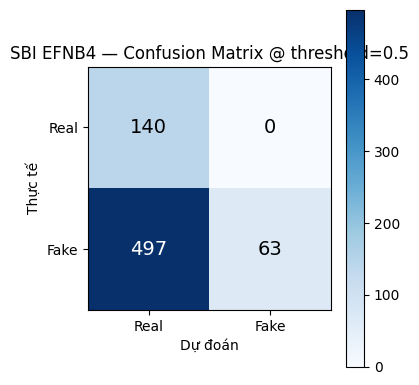

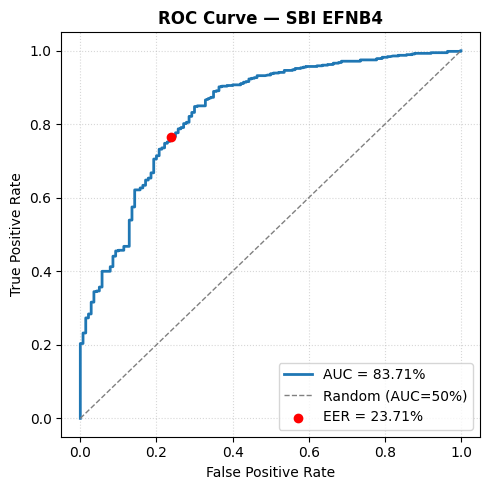

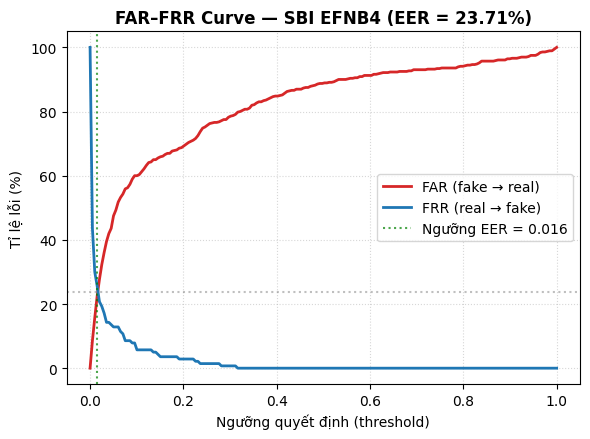


=== Breakdown theo phương pháp (real + từng loại fake) ===
        method      auc      eer   n
     Deepfakes 0.921735 0.142857 280
     Face2Face 0.854566 0.214286 280
      FaceSwap 0.827985 0.250000 280
NeuralTextures 0.744235 0.300000 280

✓ Đã lưu /kaggle/working/sbi_v1/test_results_intra.csv (schema thống nhất 5 model)


In [12]:
class VideoEvalDataset(Dataset):
    """Giống hệt pattern dùng ở UCF/Xception -- video-level eval, trả thêm `method` để breakdown."""
    def __init__(self, df):
        self.rows = []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if files: self.rows.append((row.video_id, files, row.label, row.method))
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        vid_id, files, label, method = self.rows[idx]
        imgs = []
        for f in files:
            img = cv2.imread(f)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imgs.append(to_tensor_norm(img))
        return torch.stack(imgs), label, method, vid_id


test_ds = VideoEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test videos: {len(test_ds)}")

# Tắt gradient checkpointing khi inference (chỉ cần cho training)
if hasattr(model, "set_grad_checkpointing"):
    model.set_grad_checkpointing(enable=False)

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Nạp checkpoint epoch {ckpt['epoch']} (phase={ckpt.get('phase','?')}, "
      f"val_auc={ckpt['val_metrics']['auc']:.4f})")


@torch.no_grad()
def evaluate_test_tta(model, loader):
    model.eval()
    y_true, y_score, methods, losses = [], [], [], []
    bce = nn.BCEWithLogitsLoss()
    for frames, label, method, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)
        frames_flip = torch.flip(frames, dims=[3])

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits_orig = model(frames).squeeze(1)
            logits_flip = model(frames_flip).squeeze(1)

        prob_orig = torch.sigmoid(logits_orig).mean()
        prob_flip = torch.sigmoid(logits_flip).mean()
        prob = ((prob_orig + prob_flip) / 2).item()

        label_dev = torch.tensor([float(label.item())], device=DEVICE)
        mean_logits = (logits_orig.mean(dim=0, keepdim=True) + logits_flip.mean(dim=0, keepdim=True)) / 2
        losses.append(bce(mean_logits, label_dev).item())

        y_score.append(prob); y_true.append(label.item()); methods.append(method[0])
    return np.asarray(y_true), np.asarray(y_score), np.asarray(methods), float(np.mean(losses))


y_true, y_score, methods, test_loss = evaluate_test_tta(model, test_loader)
test_metrics = calc_metrics(y_true, y_score)
test_metrics["loss"] = test_loss

print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — SBI EFNB4 baseline (TTA=hflip) ===")
print(f"Loss (BCE)          : {test_metrics['loss']:.4f}")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"Ngưỡng tại EER      : {test_metrics['eer_threshold']:.4f}")
print(f"FAR @ ngưỡng EER    : {test_metrics['far_at_eer']*100:.2f}%")
print(f"FRR @ ngưỡng EER    : {test_metrics['frr_at_eer']*100:.2f}%")

print("\n=== Ma trận nhầm lẫn @ threshold=0.5 ===")
cm = test_metrics["cm_at_0.5"]
print("                 Dự đoán Real   Dự đoán Fake")
print(f"Thực tế Real      {cm[0,0]:>10d}   {cm[0,1]:>12d}")
print(f"Thực tế Fake      {cm[1,0]:>10d}   {cm[1,1]:>12d}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title("SBI EFNB4 — Confusion Matrix @ threshold=0.5")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=100)
plt.show()

# ---- ROC curve — MỚI ----
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (AUC=50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]], color="red", zorder=5,
           label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — SBI EFNB4", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

# ---- FAR-FRR curve — MỚI ----
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.7,
           label=f"Ngưỡng EER = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Ngưỡng quyết định (threshold)"); ax.set_ylabel("Tỉ lệ lỗi (%)")
ax.set_title(f"FAR–FRR Curve — SBI EFNB4 (EER = {test_metrics['eer']*100:.2f}%)", fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()

# ---- Breakdown AUC/EER theo từng phương pháp fake ----
rows = []
real_mask = (methods == "original")
for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    mask = real_mask | (methods == m)
    yt, ys = y_true[mask], y_score[mask]
    if len(np.unique(yt)) < 2:
        rows.append({"method": m, "auc": float("nan"), "eer": float("nan"), "n": int(mask.sum())})
        continue
    rows.append({"method": m, "auc": roc_auc_score(yt, ys), "eer": calc_eer(yt, ys), "n": int(mask.sum())})

bd = pd.DataFrame(rows)
print("\n=== Breakdown theo phương pháp (real + từng loại fake) ===")
print(bd.to_string(index=False))

gpu_hours = float(np.sum(EPOCH_TIMES)) / 3600.0
result_row = {
    "model": "SBI-EFNB4", "input_modality": "spatial_rgb",
    "params_M": round(n_params / 1e6, 2),
    "epochs_planned": N_EPOCHS, "epochs_run": int(hist_df["epoch"].max()),
    "best_epoch": int(ckpt["epoch"]), "checkpoint_criterion": CHECKPOINT_CRITERION,
    "tta_used": TTA_USED, "gpu_hours": round(gpu_hours, 2),
    "loss_intra": test_metrics["loss"], "acc_intra": test_metrics["acc"],
    "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
for _, r in bd.iterrows():
    result_row[f"auc_{r['method']}"] = r["auc"]
    result_row[f"eer_{r['method']}"] = r["eer"]

pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\n✓ Đã lưu {OUT_DIR}/test_results_intra.csv (schema thống nhất 5 model)")


## 11. Biểu đồ huấn luyện

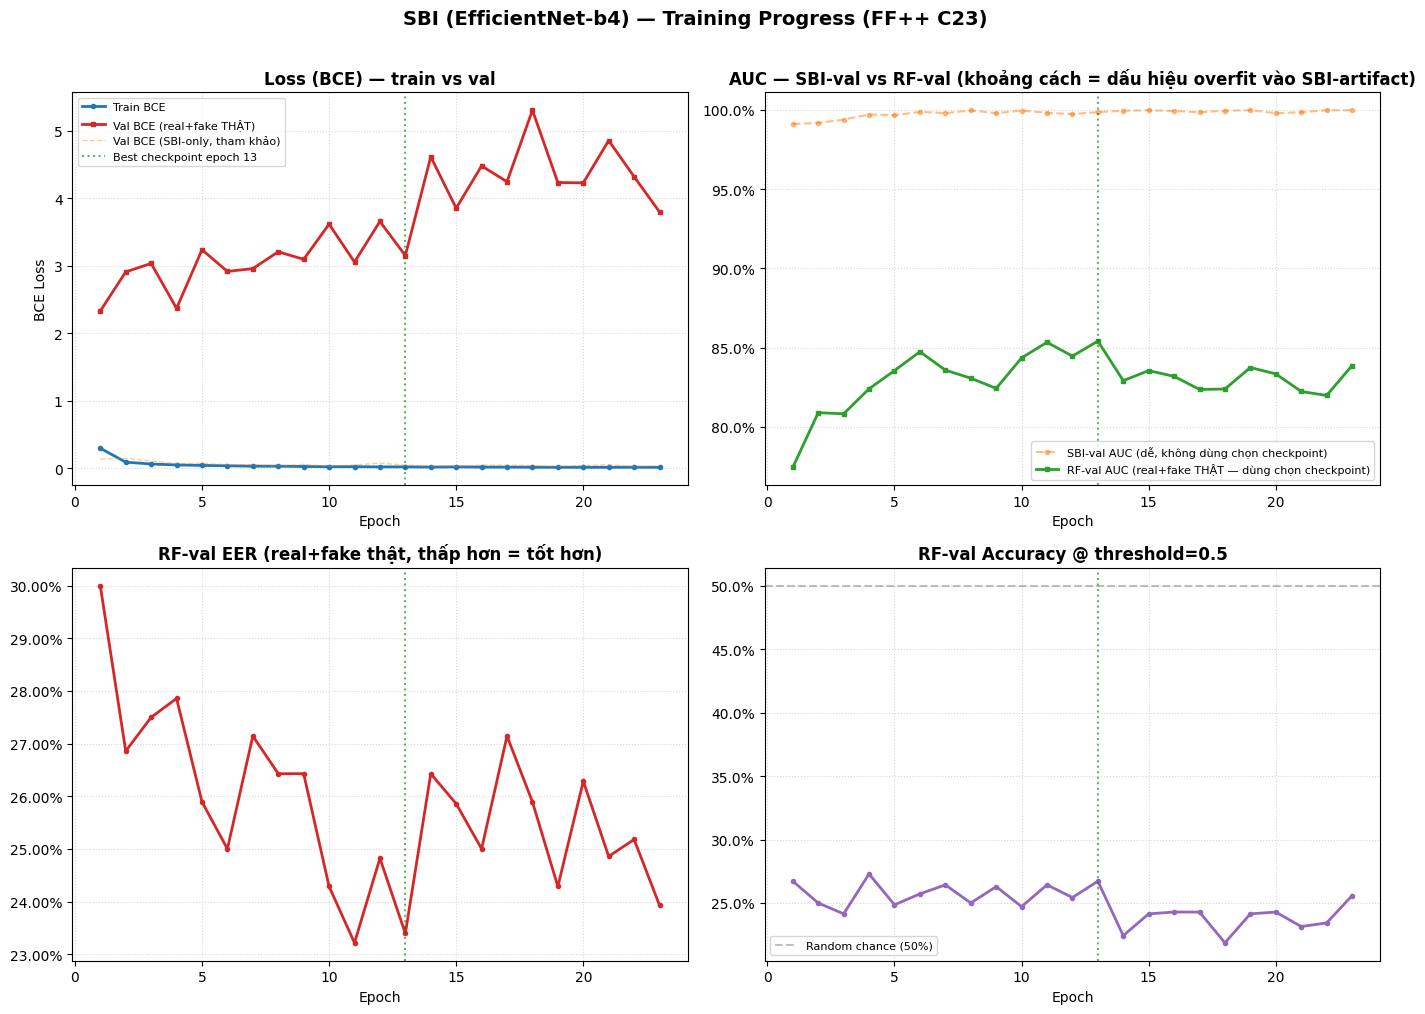

Best checkpoint: epoch 13 (val_rf_auc=0.8541, val_rf_loss=3.1505) -- đây MỚI là epoch thật sự được lưu làm sbi_best.pth.
Khoảng cách SBI-val AUC vs RF-val AUC ở epoch cuối: 16.1 điểm phần trăm -- càng lớn càng cho thấy model học artifact SBI-specific thay vì đặc trưng tổng quát.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))
x = hist_df["epoch"]

# SỬA: checkpoint chọn theo val_rf_auc (real+fake thật), nên "best epoch" trên biểu đồ PHẢI
# lấy theo đúng cột này -- bản trước lấy theo val_auc (SBI-only, gần như luôn ~0.99, sai lệch
# hoàn toàn với epoch checkpoint thật sự được lưu).
best_idx = hist_df["val_rf_auc"].idxmax()
best_epoch = hist_df.loc[best_idx, "epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (0,0): Train loss vs Val loss -- SỬA: vẽ val_rf_loss (real+fake thật) làm đường CHÍNH,
# val_loss (SBI-only) chỉ vẽ mờ để tham khảo, tránh gây hiểu lầm như bản cũ ---
axes[0, 0].plot(x, hist_df["train_loss"], "o-", lw=2, ms=3, label="Train BCE", color="#1f77b4")
axes[0, 0].plot(x, hist_df["val_rf_loss"], "s-", lw=2, ms=3,
                label="Val BCE (real+fake THẬT)", color="#d62728")
axes[0, 0].plot(x, hist_df["val_loss"], "--", lw=1, ms=2, alpha=0.4,
                label="Val BCE (SBI-only, tham khảo)", color="#ff7f0e")
axes[0, 0].axvline(best_epoch, color="green", linestyle=":", alpha=0.6,
                   label=f"Best checkpoint epoch {int(best_epoch)}")
axes[0, 0].set_title("Loss (BCE) — train vs val", fontweight="bold")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, ls=":", alpha=0.5)

# --- (0,1): AUC -- so sánh trực tiếp SBI-val (dễ, bão hòa nhanh) với RF-val (thật sự quan
# trọng) trên CÙNG 1 biểu đồ -- đây chính là bằng chứng trực quan cho thấy model overfit vào
# SBI-artifact chứ không tổng quát hoá (khoảng cách giữa 2 đường càng rộng càng đáng lo) ---
axes[0, 1].plot(x, hist_df["val_auc"] * 100, "o--", lw=1.5, ms=3, alpha=0.5,
                label="SBI-val AUC (dễ, không dùng chọn checkpoint)", color="#ff7f0e")
axes[0, 1].plot(x, hist_df["val_rf_auc"] * 100, "s-", lw=2, ms=3,
                label="RF-val AUC (real+fake THẬT — dùng chọn checkpoint)", color="#2ca02c")
axes[0, 1].axvline(best_epoch, color="green", linestyle=":", alpha=0.6)
axes[0, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
axes[0, 1].set_title("AUC — SBI-val vs RF-val (khoảng cách = dấu hiệu overfit vào SBI-artifact)",
                     fontweight="bold")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, ls=":", alpha=0.5)

# --- (1,0): RF-val EER ---
axes[1, 0].plot(x, hist_df["val_rf_eer"] * 100, "o-", lw=2, ms=3, color="#d62728")
axes[1, 0].axvline(best_epoch, color="green", linestyle=":", alpha=0.6)
axes[1, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
axes[1, 0].set_title("RF-val EER (real+fake thật, thấp hơn = tốt hơn)", fontweight="bold")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].grid(True, ls=":", alpha=0.5)

# --- (1,1): RF-val Accuracy @ threshold 0.5 -- theo dõi riêng vì đây là chỗ model đang tệ
# nhất (acc ~21-24%, thấp hơn nhiều so với AUC ~70% -- dấu hiệu ngưỡng 0.5 bị lệch/miscalibrate) ---
axes[1, 1].plot(x, hist_df["val_rf_acc"] * 100, "o-", lw=2, ms=3, color="#9467bd")
axes[1, 1].axhline(50, color="gray", linestyle="--", alpha=0.5, label="Random chance (50%)")
axes[1, 1].axvline(best_epoch, color="green", linestyle=":", alpha=0.6)
axes[1, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
axes[1, 1].set_title("RF-val Accuracy @ threshold=0.5", fontweight="bold")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, ls=":", alpha=0.5)

plt.suptitle("SBI (EfficientNet-b4) — Training Progress (FF++ C23)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

best_ep = hist_df.loc[best_idx]
print(f"Best checkpoint: epoch {int(best_ep['epoch'])} "
      f"(val_rf_auc={best_ep['val_rf_auc']:.4f}, val_rf_loss={best_ep['val_rf_loss']:.4f}) "
      f"-- đây MỚI là epoch thật sự được lưu làm sbi_best.pth.")
gap = (hist_df["val_auc"] - hist_df["val_rf_auc"]).iloc[-1]
print(f"Khoảng cách SBI-val AUC vs RF-val AUC ở epoch cuối: {gap*100:.1f} điểm phần trăm -- "
      f"càng lớn càng cho thấy model học artifact SBI-specific thay vì đặc trưng tổng quát.")


## ⚠️ Lưu kết quả
**Save Version → Save & Run All (Commit)** → Output → New Dataset

Thư mục `/kaggle/working/sbi_v1/` sẽ có:
- `sbi_best.pth` — checkpoint được chọn theo đúng quy tắc paper (epoch lớn nhất trong top-5 val_auc)
- `train_history.csv`, `test_results_intra.csv` — đúng schema thống nhất 5 model
- `confusion_matrix.png`, `training_curves.png`

⏱️ **Lưu ý thời gian:** 100 epoch × SAM (2 forward-backward/batch) × EfficientNet-b4 380px +
sinh SBI on-the-fly (dlib landmark đã cache sẵn nên không phải nút thắt, nhưng albumentations +
warpAffine trên CPU mỗi ảnh vẫn tốn thời gian) — có thể mất nhiều giờ trên GPU T4 của Kaggle.
Cân nhắc giảm `N_EPOCHS`/tăng `PATIENCE` sớm hơn nếu vượt quá giới hạn phiên chạy.
